In [1]:
import requests
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
#%inline matplotlib
from scipy import stats # statistics
import sklearn.metrics as metrics # metrics for model evaluation
from matplotlib.pyplot import figure
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.patches as mpatches

In [2]:
data = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/outdoor_reference_based_analysis_data.csv")

In [3]:
data

,file,measured_area_cm2,predicted_area_cm2
0,171,199.382,180.643924
1,173,564.880,375.583984
2,174,1292.670,1051.007347
3,176,740.657,629.504848
4,178,1758.409,1518.634039
...,...,...,...
56,237,62.380,57.902902
57,238,72.236,66.770662
58,239,44.196,74.785011
59,240,44.971,61.491535


In [4]:
def Bias(pred, obs):
    return pred - obs

def relBias(pred, obs):
    return ((pred - obs) / obs) * 100

data["bias"] = data.apply(lambda x: Bias(x.predicted_area_cm2 , x.measured_area_cm2 ), axis=1)
data["relBias"] = data.apply(lambda x: relBias(x.predicted_area_cm2, x.measured_area_cm2), axis=1)

In [5]:
data = data[data['predicted_area_cm2'] != 0.0]

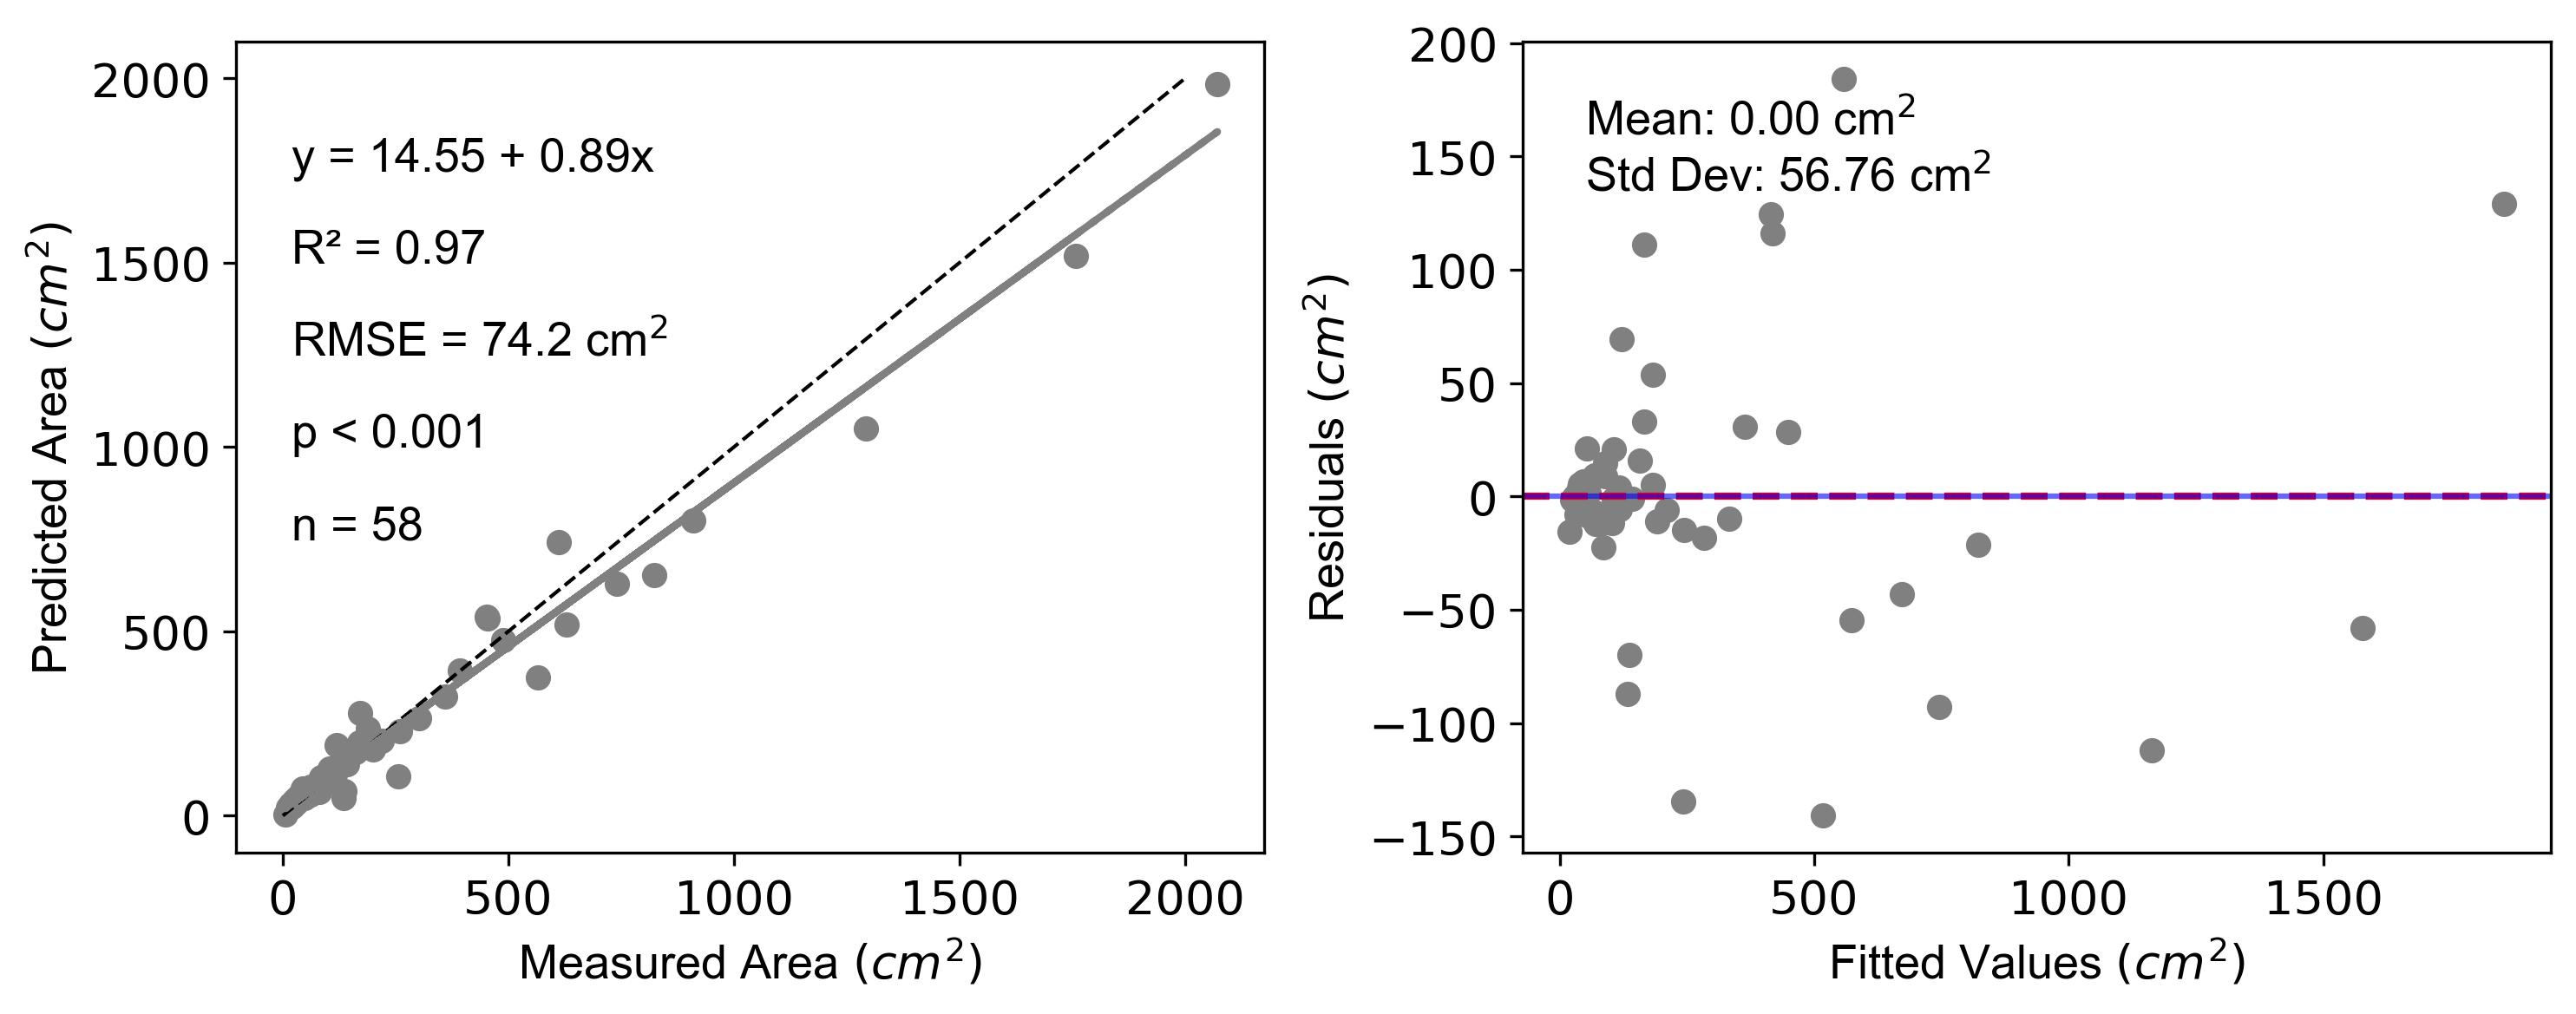

In [7]:
# =============================================================================
# TWO-PANEL PLOT: PREDICTION vs MEASURED + RESIDUALS
# With p-value added and increased font sizes
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Your data
x = np.array(data['measured_area_cm2'])
y = np.array([float(val) for val in data['predicted_area_cm2']])

# Fit regression and get p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
a, b = slope, intercept  # For compatibility with your code

# Calculate metrics
rmse = np.sqrt(mean_squared_error(x, y))
r2 = r2_score(x, y)

# Calculate residuals
y_pred = a * x + b
residuals = y - y_pred

# Font settings
font = {'fontname': 'Arial'}

# Create figure with two subplots
figure(figsize=(10, 4), dpi=300)

# ============================================================
# PANEL 1: Scatter plot with regression (LEFT)
# ============================================================
plt.subplot(1, 2, 1)

# 1:1 line
plt.plot(np.arange(2000), np.arange(2000), color='black', linestyle='--', linewidth=1)

# Scatter points
plt.scatter(x, y, color='gray')

# Regression line
plt.plot(x, a*x + b, linestyle='--', linewidth=2, color='gray')

# Labels
plt.xlabel("Measured Area $\\left( cm^2 \\right)$", size=13, **font)
plt.ylabel("Predicted Area $\\left( cm^2 \\right)$", size=13, **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Add statistics as text
plt.text(20, 1750, 'y = ' + '{:.2f}'.format(b) + ' + {:.2f}'.format(a) + 'x', size=13, **font)
plt.text(20, 1500, f"R² = {round(r2, 2)}", size=13, **font)
plt.text(20, 1250, f"RMSE = {round(rmse, 2)} cm$^2$", size=13, **font)
plt.text(20, 1000, f"p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}", size=13, **font)
plt.text(20, 750, f"n = {len(data)}", size=13, **font)

# Grid
#plt.grid(True, alpha=0.3)

# ============================================================
# PANEL 2: Residual plot (RIGHT)
# ============================================================
plt.subplot(1, 2, 2)

# Scatter residuals vs fitted values
plt.scatter(y_pred, residuals, color='gray')

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Mean residual line (optional)
mean_res = np.mean(residuals)
plt.axhline(y=mean_res, color='blue', linestyle='-', linewidth=1.5, alpha=0.6)

# Labels
plt.xlabel("Fitted Values $\\left( cm^2 \\right)$", size=13, **font)
plt.ylabel("Residuals $\\left( cm^2 \\right)$", size=13, **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Add residual statistics
std_res = np.std(residuals)
plt.text(50, 160, f"Mean: {mean_res:.2f} cm$^2$", size=13, **font)
plt.text(50, 135, f"Std Dev: {std_res:.2f} cm$^2$", size=13, **font)

# Grid
#plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show
plt.show()

# Optional: Save the figure
# plt.savefig('prediction_residual_analysis.png', dpi=600, bbox_inches='tight')

In [8]:
data = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_reference_based_analysis_data.csv")

In [9]:
data

,file,measured_area_cm2,predicted_area_cm2
0,PXL_20240214_172530114_80cm_F6_.jpg,51.309575,45.372639
1,PXL_20240214_173554009_80cm_F11_.jpg,3.367735,3.303557
2,PXL_20240214_175708911_100cm_F23_.jpg,35.916057,32.584215
3,PXL_20240214_175352365_100cm_F21_.jpg,19.696735,18.239009
4,PXL_20240214_174000188_80cm_F13_.jpg,131.586834,131.530978
...,...,...,...
70,PXL_20240214_172357833_80cm_F5_.jpg,18.845124,11.318141
71,PXL_20240214_173607901_60cm_F11_.jpg,3.535477,3.450452
72,PXL_20240214_174741393_100cm_F16_.jpg,54.606342,55.910964
73,PXL_20240214_172516412_100cm_F6_.jpg,41.935400,36.670874


In [10]:
def Bias(pred, obs):
    return pred - obs

def relBias(pred, obs):
    return ((pred - obs) / obs) * 100

data["bias"] = data.apply(lambda x: Bias(x.predicted_area_cm2 , x.measured_area_cm2 ), axis=1)
data["relBias"] = data.apply(lambda x: relBias(x.predicted_area_cm2, x.measured_area_cm2), axis=1)

In [11]:
#data = data[data['predicted_area_cm2'] != 0.0]

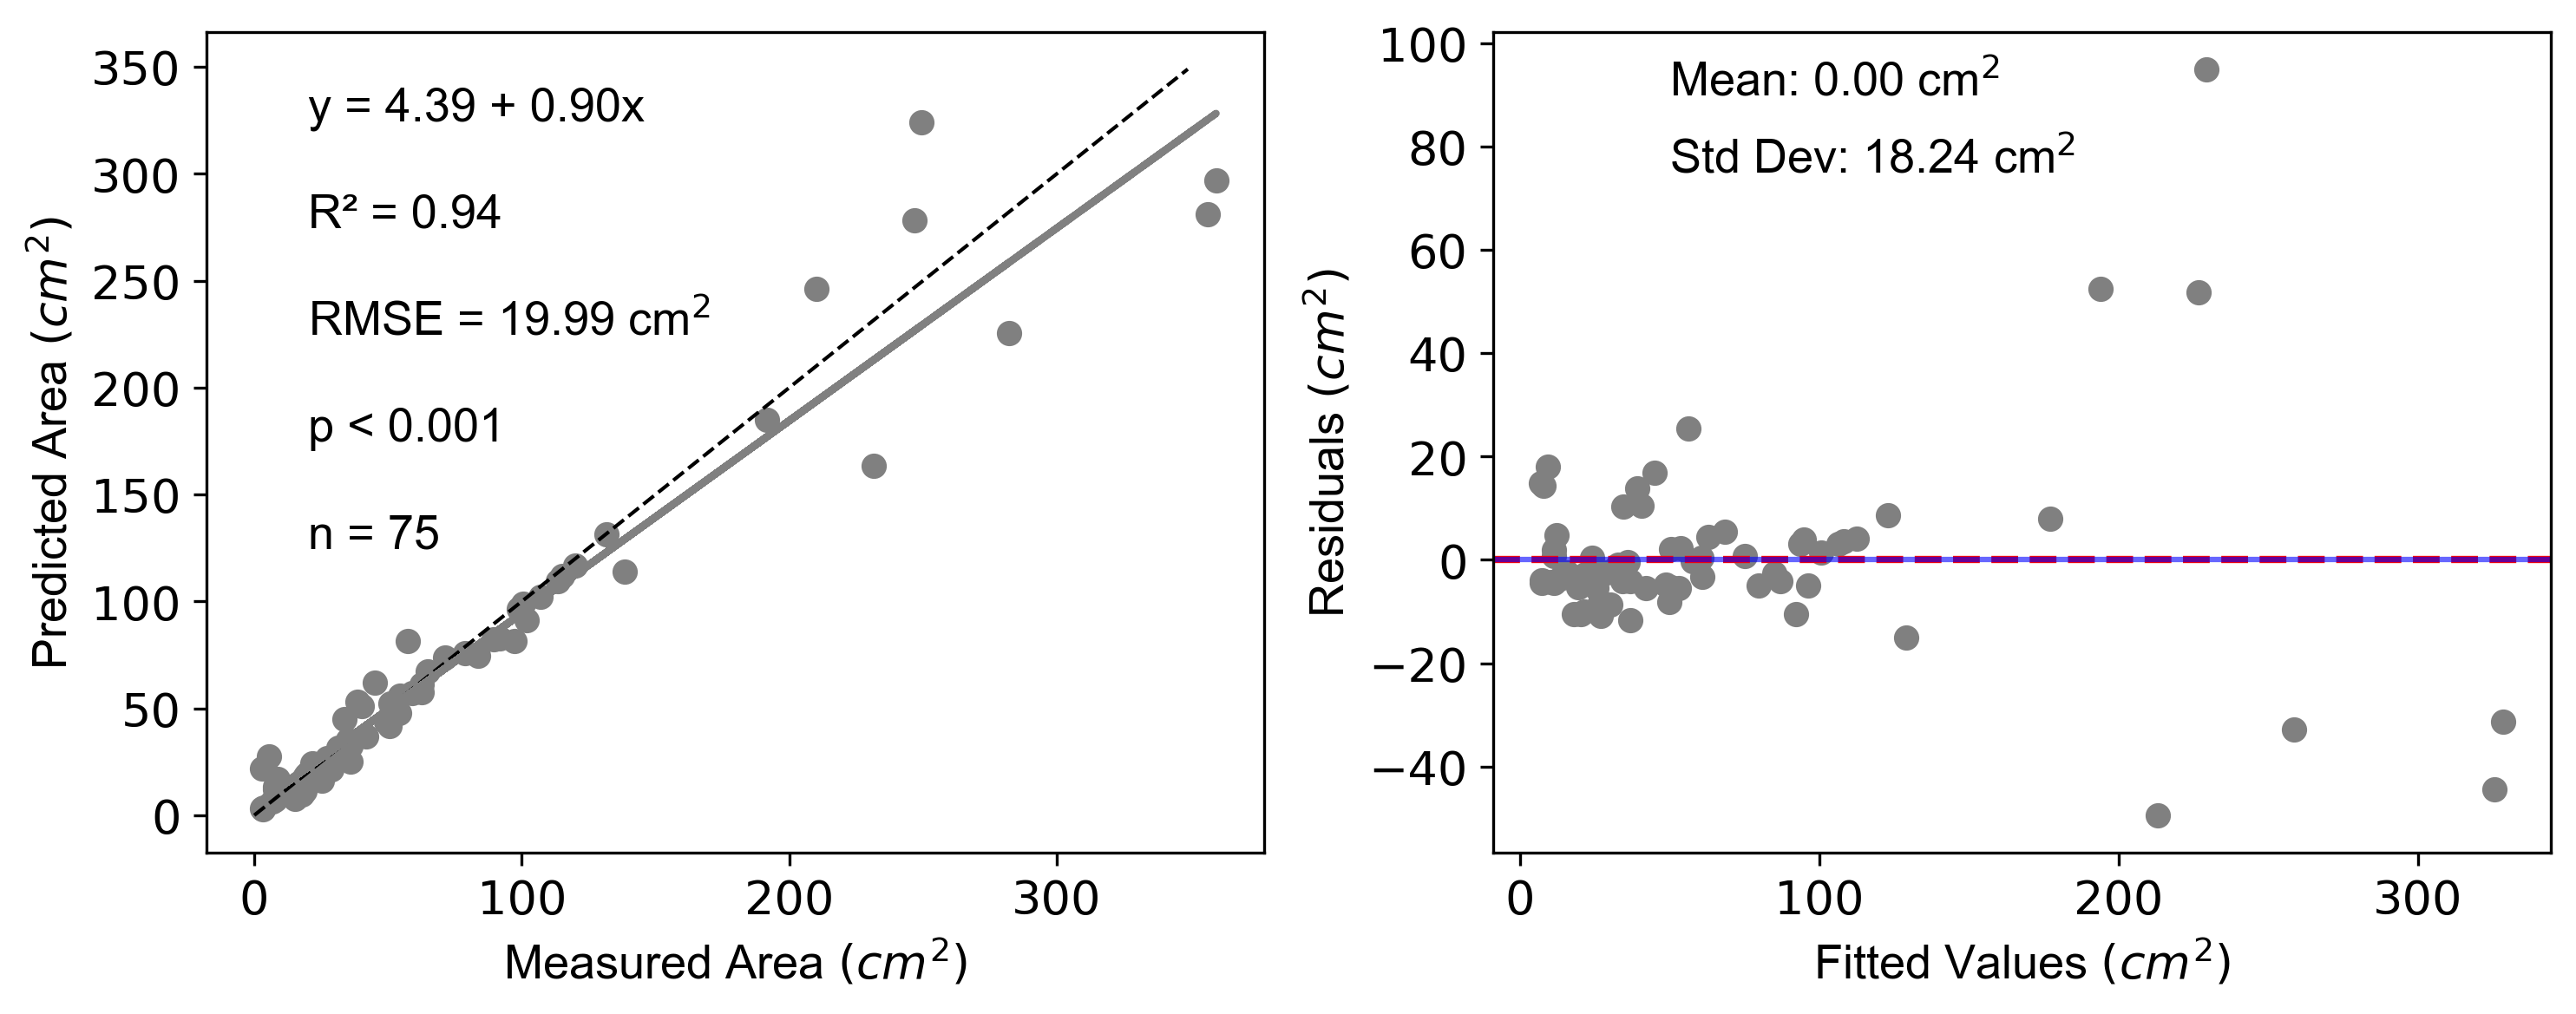

In [12]:
# =============================================================================
# TWO-PANEL PLOT: PREDICTION vs MEASURED + RESIDUALS
# With p-value added and increased font sizes
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Your data
x = np.array(data['measured_area_cm2'])
y = np.array([float(val) for val in data['predicted_area_cm2']])

# Fit regression and get p-value
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
a, b = slope, intercept  # For compatibility with your code

# Calculate metrics
rmse = np.sqrt(mean_squared_error(x, y))
r2 = r2_score(x, y)

# Calculate residuals
y_pred = a * x + b
residuals = y - y_pred

# Font settings
font = {'fontname': 'Arial'}

# Create figure with two subplots
figure(figsize=(10, 4), dpi=300)

# ============================================================
# PANEL 1: Scatter plot with regression (LEFT)
# ============================================================
plt.subplot(1, 2, 1)

# 1:1 line
plt.plot(np.arange(350), np.arange(350), color='black', linestyle='--', linewidth=1)

# Scatter points
plt.scatter(x, y, color='gray')

# Regression line
plt.plot(x, a*x + b, linestyle='--', linewidth=2, color='gray')

# Labels
plt.xlabel("Measured Area $\\left( cm^2 \\right)$", size=13, **font)
plt.ylabel("Predicted Area $\\left( cm^2 \\right)$", size=13, **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Add statistics as text
plt.text(20, 325, 'y = ' + '{:.2f}'.format(b) + ' + {:.2f}'.format(a) + 'x', size=13, **font)
plt.text(20, 275, f"R² = {round(r2, 2)}", size=13, **font)
plt.text(20, 225, f"RMSE = {round(rmse, 2)} cm$^2$", size=13, **font)
plt.text(20, 175, f"p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}", size=13, **font)
plt.text(20, 125, f"n = {len(data)}", size=13, **font)

# Grid
#plt.grid(True, alpha=0.3)

# ============================================================
# PANEL 2: Residual plot (RIGHT)
# ============================================================
plt.subplot(1, 2, 2)

# Scatter residuals vs fitted values
plt.scatter(y_pred, residuals, color='gray')

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Mean residual line (optional)
mean_res = np.mean(residuals)
plt.axhline(y=mean_res, color='blue', linestyle='-', linewidth=1.5, alpha=0.6)

# Labels
plt.xlabel("Fitted Values $\\left( cm^2 \\right)$", size=13, **font)
plt.ylabel("Residuals $\\left( cm^2 \\right)$", size=13, **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Add residual statistics
std_res = np.std(residuals)
plt.text(50, 90, f"Mean: {mean_res:.2f} cm$^2$", size=13, **font)
plt.text(50, 75, f"Std Dev: {std_res:.2f} cm$^2$", size=13, **font)

# Grid
#plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Show
plt.show()

# Optional: Save the figure
# plt.savefig('prediction_residual_analysis.png', dpi=600, bbox_inches='tight')

In [13]:
data = pd.read_csv("/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_distance_based_analysis_data.csv")

In [14]:
data

,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_referenbase_based_area_cm2
0,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,20.296706,18.239009
1,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,19.537758,25.096238
2,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,102.626389,96.598299
3,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,22.563655,21.890223
4,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,132.928302,163.579053
5,PXL_20240214_175016038_100cm_F18_.jpg,F18,100,27.348332,27.196349,26.554654
6,PXL_20240214_174857541_100cm_F17_.jpg,F17,100,12.445136,13.685038,13.174496
7,PXL_20240214_172902391_100cm_F7_.jpg,F7,100,83.599833,85.334637,74.760453
8,PXL_20240214_171637048_100cm_F1_.jpg,F1,100,33.593481,46.198990,44.887884
9,PXL_20240214_172812015_60cm_F7_.jpg,F7,60,119.967502,81.159198,116.620480


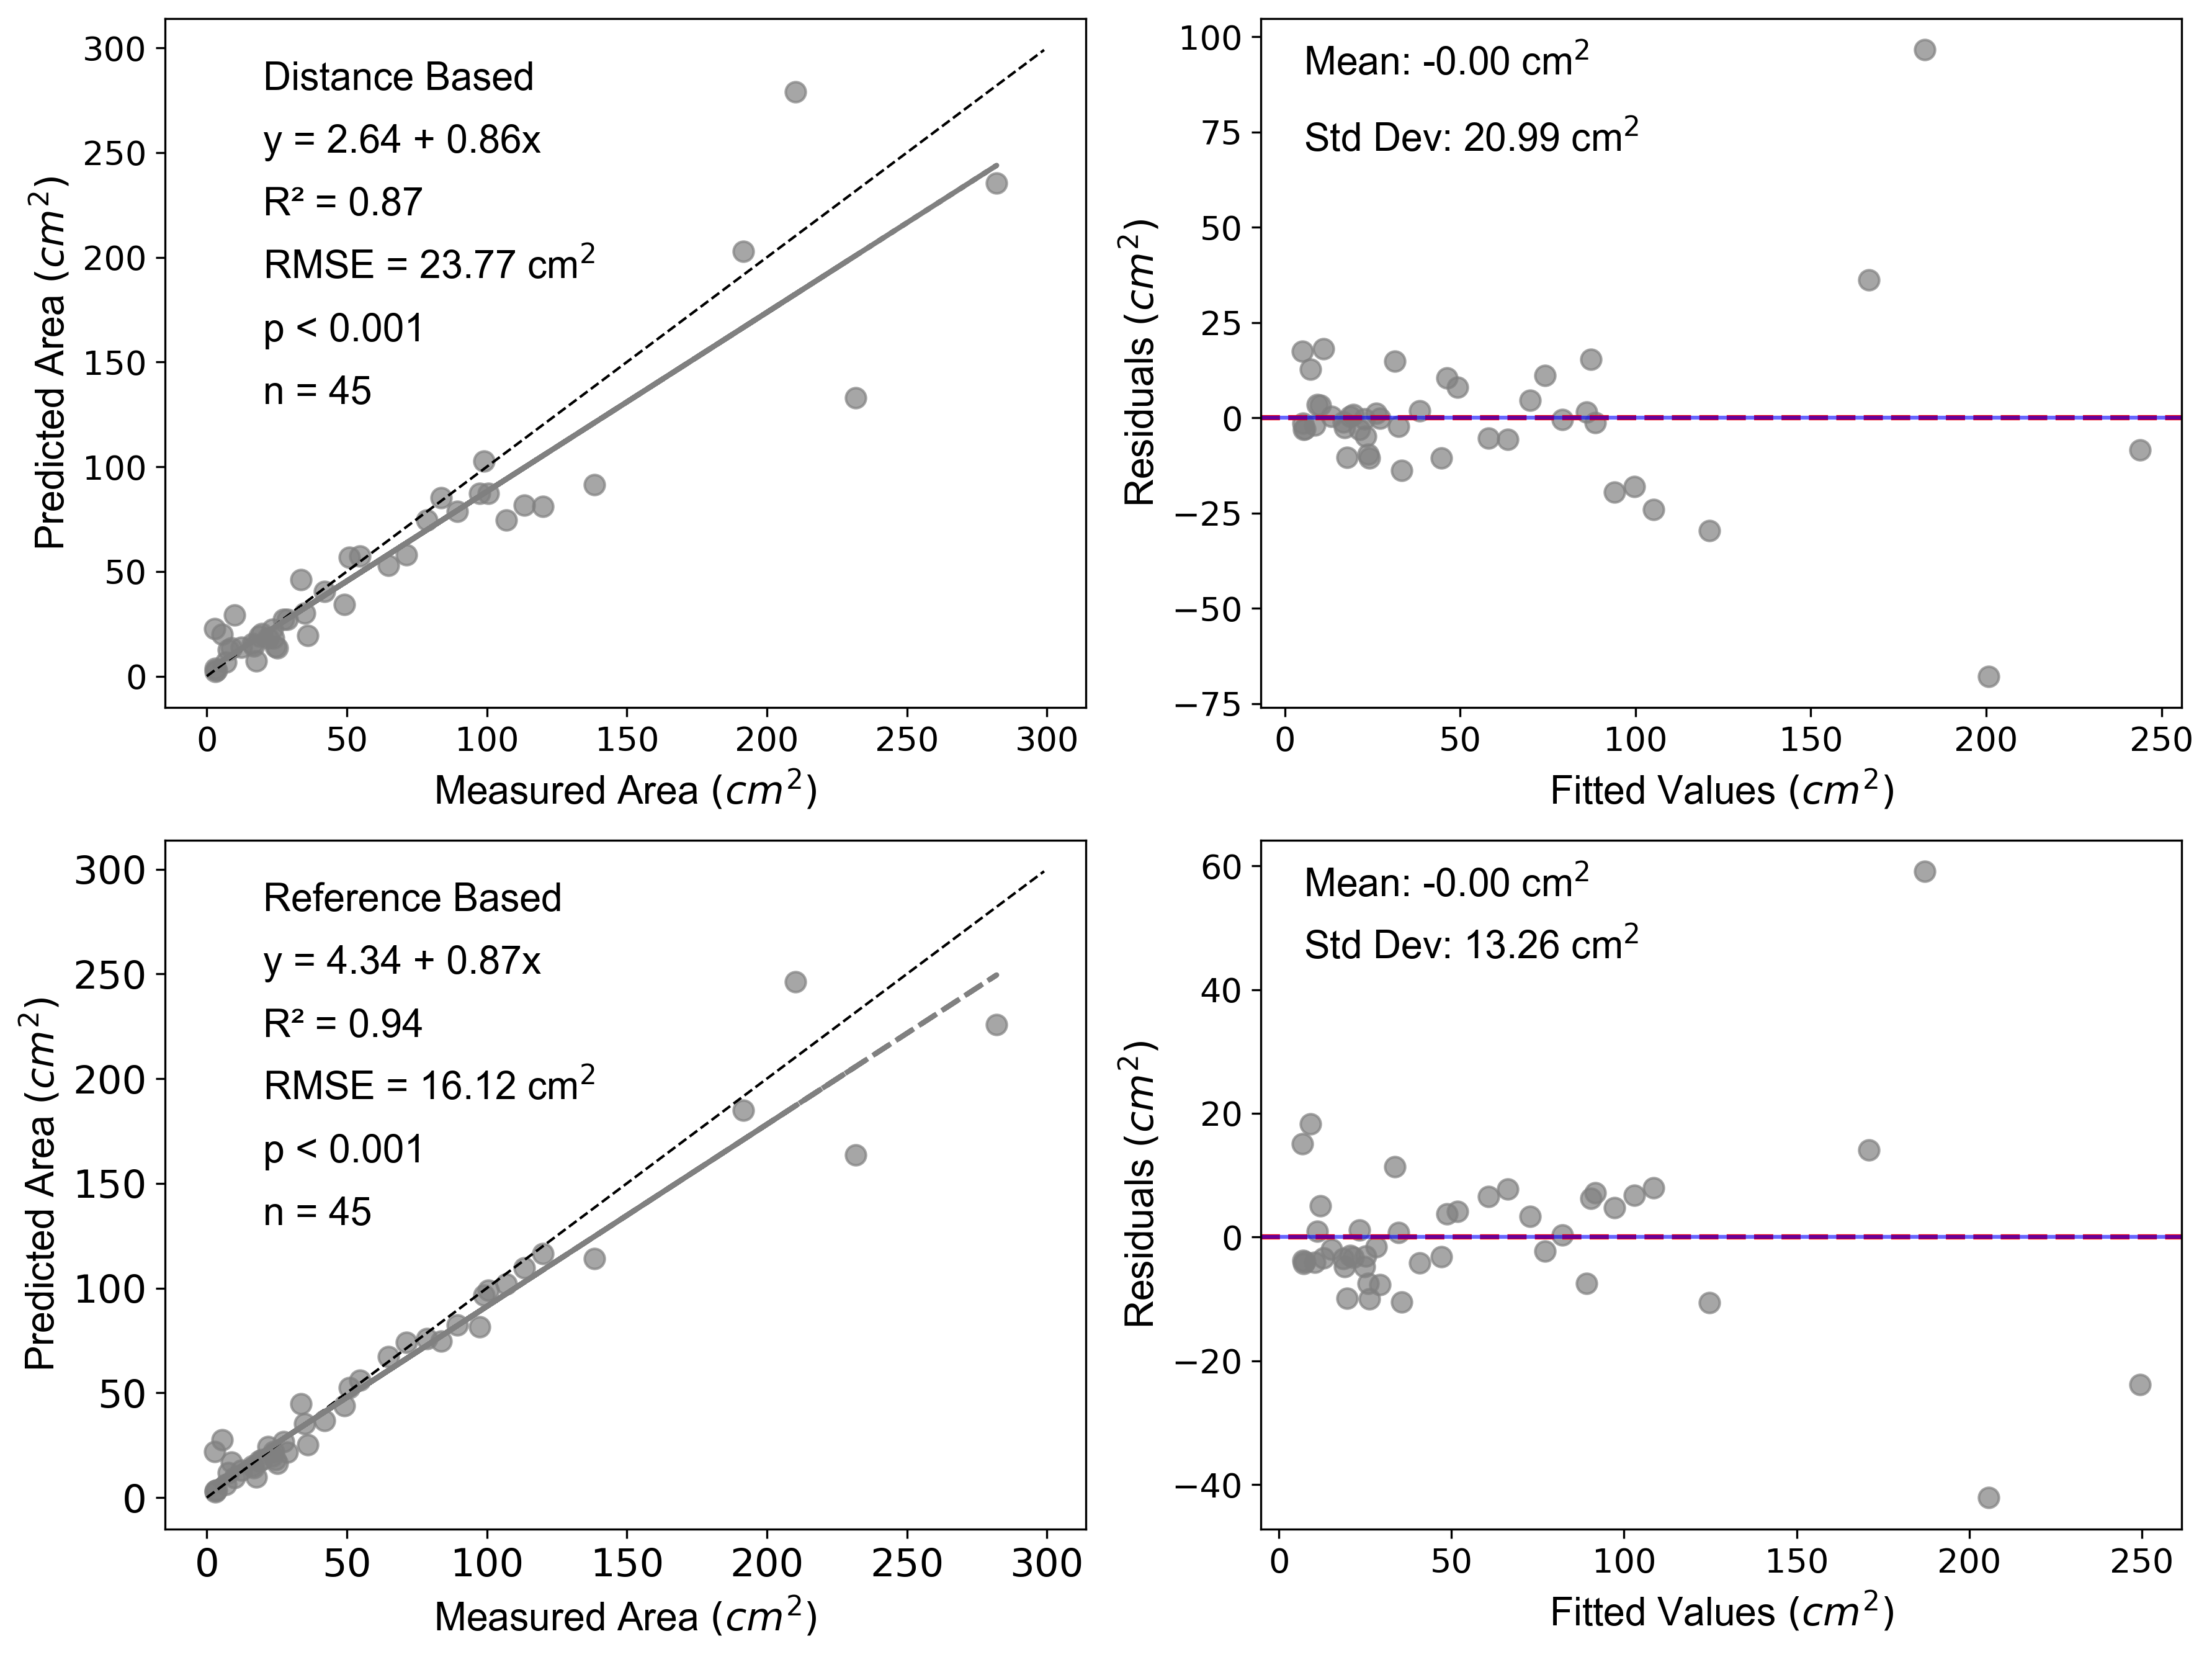

In [15]:
# =============================================================================
# FOUR-PANEL PLOT: Distance-Based (Top) & Reference-Based (Bottom)
# Each with Regression + Residual plots
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

# Your data
x = np.array(data['measured_area_cm2'])
y_distance = np.array([float(val) for val in data['predicted_distance_based_area_cm2']])
y_reference = np.array([float(val) for val in data['predicted_referenbase_based_area_cm2']])

# Font settings
font = {'fontname': 'Arial'}

# Create figure with 2x2 subplots
fig = plt.figure(figsize=(12, 9), dpi=300)

# =============================================================================
# TOP ROW: DISTANCE-BASED METHOD
# =============================================================================

# Fit regression for distance-based
slope_d, intercept_d, r_value_d, p_value_d, std_err_d = stats.linregress(x, y_distance)
rmse_d = np.sqrt(mean_squared_error(x, y_distance))
r2_d = r2_score(x, y_distance)
y_pred_d = slope_d * x + intercept_d
residuals_d = y_distance - y_pred_d

# --- PANEL 1: Distance-Based Scatter + Regression (Top Left) ---
plt.subplot(2, 2, 1)

# 1:1 line
plt.plot(np.arange(300), np.arange(300), color='black', linestyle='--', linewidth=1)

# Scatter points
plt.scatter(x, y_distance, color='gray', s=60, alpha=0.7)

# Regression line
plt.plot(x, slope_d*x + intercept_d, linestyle='--', linewidth=2, color='gray')

# Labels
plt.xlabel("Measured Area $\\left( cm^2 \\right)$", size=15, **font)
plt.ylabel("Predicted Area $\\left( cm^2 \\right)$", size=15, **font)
#plt.title("Distance-Based Measurement", size=16, fontweight='bold', **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Add statistics
plt.text(20, 280, f'Distance Based', size=15, **font)
plt.text(20, 250, 'y = ' + '{:.2f}'.format(intercept_d) + ' + {:.2f}'.format(slope_d) + 'x', size=15, **font)
plt.text(20, 220, f"R² = {r2_d:.2f}", size=15, **font)
plt.text(20, 190, f"RMSE = {rmse_d:.2f} cm$^2$", size=15, **font)
plt.text(20, 160, f"p < 0.001" if p_value_d < 0.001 else f"p = {p_value_d:.3f}", size=15, **font)
plt.text(20, 130, f"n = {len(data)}", size=15, **font)

# --- PANEL 2: Distance-Based Residuals (Top Right) ---
plt.subplot(2, 2, 2)

# Scatter residuals
plt.scatter(y_pred_d, residuals_d, color='gray', s=60, alpha=0.7)

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Mean residual line
mean_res_d = np.mean(residuals_d)
plt.axhline(y=mean_res_d, color='blue', linestyle='-', linewidth=1.5, alpha=0.6)

# Labels
plt.xlabel("Fitted Values $\\left( cm^2 \\right)$", size=15, **font)
plt.ylabel("Residuals $\\left( cm^2 \\right)$", size=15, **font)
#plt.title("Distance-Based Residuals", size=16, fontweight='bold', **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Statistics
std_res_d = np.std(residuals_d)
plt.text(min(y_pred_d)*1.05, 90, f"Mean: {mean_res_d:.2f} cm$^2$", size=15, **font)
plt.text(min(y_pred_d)*1.05, 70, f"Std Dev: {std_res_d:.2f} cm$^2$", size=15, **font)

# =============================================================================
# BOTTOM ROW: REFERENCE-BASED METHOD
# =============================================================================

# Fit regression for reference-based
slope_r, intercept_r, r_value_r, p_value_r, std_err_r = stats.linregress(x, y_reference)
rmse_r = np.sqrt(mean_squared_error(x, y_reference))
r2_r = r2_score(x, y_reference)
y_pred_r = slope_r * x + intercept_r
residuals_r = y_reference - y_pred_r

# --- PANEL 3: Reference-Based Scatter + Regression (Bottom Left) ---
plt.subplot(2, 2, 3)

# 1:1 line
plt.plot(np.arange(300), np.arange(300), color='black', linestyle='--', linewidth=1)

# Scatter points
plt.scatter(x, y_reference, color='gray', s=60, alpha=0.7)

# Regression line
plt.plot(x, slope_r*x + intercept_r, linestyle='--', linewidth=2, color='gray')

# Labels
plt.xlabel("Measured Area $\\left( cm^2 \\right)$", size=15, **font)
plt.ylabel("Predicted Area $\\left( cm^2 \\right)$", size=15, **font)
#plt.title("Reference-Based Measurement", size=16, fontweight='bold', **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=15)


# Add statistics
# plt.text(20, 280, 'y = ' + '{:.2f}'.format(intercept_d) + ' + {:.2f}'.format(slope_d) + 'x', size=15, **font)
# plt.text(20, 250, f"R² = {r2_d:.2f}", size=15, **font)
# plt.text(20, 220, f"RMSE = {rmse_d:.2f} cm$^2$", size=15, **font)
# plt.text(20, 190, f"p < 0.001" if p_value_d < 0.001 else f"p = {p_value_d:.3f}", size=15, **font)
# plt.text(20, 160, f"n = {len(data)}", size=15, **font)


# Add statistics
plt.text(20, 280, 'Reference Based', size=15, **font)
plt.text(20, 250, 'y = ' + '{:.2f}'.format(intercept_r) + ' + {:.2f}'.format(slope_r) + 'x', size=15, **font)
plt.text(20, 220, f"R² = {r2_r:.2f}", size=15, **font)
plt.text(20, 190, f"RMSE = {rmse_r:.2f} cm$^2$", size=15, **font)
plt.text(20, 160, f"p < 0.001" if p_value_r < 0.001 else f"p = {p_value_r:.3f}", size=15, **font)
plt.text(20, 130, f"n = {len(data)}", size=15, **font)

# --- PANEL 4: Reference-Based Residuals (Bottom Right) ---
plt.subplot(2, 2, 4)

# Scatter residuals
plt.scatter(y_pred_r, residuals_r, color='gray', s=60, alpha=0.7)

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Mean residual line
mean_res_r = np.mean(residuals_r)
plt.axhline(y=mean_res_r, color='blue', linestyle='-', linewidth=1.5, alpha=0.6)

# Labels
plt.xlabel("Fitted Values $\\left( cm^2 \\right)$", size=15, **font)
plt.ylabel("Residuals $\\left( cm^2 \\right)$", size=15, **font)
#plt.title("Reference-Based Residuals", size=16, fontweight='bold', **font)

# Increase tick label font size
plt.tick_params(axis='both', which='major', labelsize=13)

# Statistics
std_res_r = np.std(residuals_r)
plt.text(min(y_pred_r)*1.05, 55, f"Mean: {mean_res_r:.2f} cm$^2$", size=15, **font)
plt.text(min(y_pred_r)*1.05, 45, f"Std Dev: {std_res_r:.2f} cm$^2$", size=15, **font)

# =============================================================================
# Adjust layout and show
# =============================================================================
plt.tight_layout()
plt.show()

# Optional: Save the figure
# plt.savefig('method_comparison_4panel.png', dpi=300, bbox_inches='tight')